<a href="https://colab.research.google.com/github/redinbluesky/llm-from-scratch/blob/main2/07_지시를_따르도록_미세_튜닝하기.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 지시를 따르도록 미세 튜닝하기 목차
* [Chapter 1 지시 미세 튜닝 소개](#chapter1)
* [Chapter 2 지도 학습 지시 미세 튜닝을 위해 데이터셋 준비하기](#chapter2)
* [Chapter 3 훈련 배치 만들기](#chapter3)
* [Chapter 4 지시 데이터셋을 위한 데이터 로더 만들기](#chapter4)
* [Chapter 5 사전 훈련된 LLM 로드하기](#chapter5)
* [Chapter 6 지시 데이터에서 LLM 미세 튜닝하기](#chapter6)
* [Chapter 7 응답을 추출하여 저장하기](#chapter7)
* [Chapter 8 미세 튜닝된 LLM 평가하기](#chapter8)

## Chapter 1 지시 미세 튜닝 소개 <a class="anchor" id="chapter1"></a>
1. LLM을 사전 훈련하는 것은 한번에 한 단어씩 생성하는 방법을 배우는 것입니다.
   - 이렇게 만들어진 사전 훈련된 LLM은 텍스트 완성능력이 있다.
   - "이 텍스트 문법을 고쳐 줘"와 같은 구체적인 명령을 잘 수행하지 못합니다.

2. 지시를 따르고 기대하는 응답을 생성하도록 LLM 능력을 향상시켜봅시다.

    ![예시](image/07-01-example5.png)

3. 지시 미세튜닝은 세 단계 과정을 거친다.

   ![순서](image/07-01-process3.png)

## Chapter 2 지도 학습 지시 미세 튜닝을 위해 데이터셋 준비하기 <a class="anchor" id="chapter2"></a>
1. 지시 미세 튜닝을 위해서는 지시와 그에 대한 응답이 포함된 데이터셋이 필요하다.
   - 예: "이 텍스트 문법을 고쳐 줘" -> "고쳐진 텍스트"

In [1]:
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

# 책에서는 다음 코드를 사용했지만 VPN을 사용하는 경우 urllib가 문제를 일으킬 수 있습니다.
# 따라서 더 안정적인 `requests` 패키지를 사용합니다.

"""
import urllib

def download_and_load_file(file_path, url):

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data
"""


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("샘플 개수:", len(data))

# 연습문제 7.3: 원본 Alpaca 데이터셋에서 파인튜닝
url2 = "https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json"

data_alpaca = download_and_load_file("alpaca_data.json", url2)
print("샘플 개수:", len(data_alpaca))


샘플 개수: 1100
샘플 개수: 52002


2. 샘플 데이터 양식은 'instruction', 'input', 'output' 키로 구성된 파이썬 딕셔너리의 리스트이다.
    - 'instruction': 모델이 수행해야 할 작업 지시
    - 'input': 작업에 필요한 추가 정보(없을 수도 있음)
    - 'output': 모델이 생성해야 할 기대 응답

In [2]:
# 샘플 데이터 출력
#   - 'instruction', 'input', 'output' 키로 구성된 파이썬 딕셔너리의 리스트
print("샘플 데이터 예시:\n", data[50])

# input 필드가 비어있는 경우도 있음
#   - 
print("다른 샘플 데이터 예시:\n", data[999])

print("샘플 데이터 예시 알파카:\n", data_alpaca[50])

샘플 데이터 예시:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}
다른 샘플 데이터 예시:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}
샘플 데이터 예시 알파카:
 {'instruction': 'Edit the following sentence to make it more concise.', 'input': 'He ran to the bus stop in order to catch the bus that was due to arrive in five minutes.', 'output': 'He ran to the bus stop, due to arrive in five minutes.'}



3. input 필드가 비어있는 경우도 있음
   - 예: "이 텍스트 문법을 고쳐 줘" -> "고쳐진 텍스트"

4. LLM을 위해 샘플을 포멧팅하는 방법은 여러가지가 있다.
   - 알파카(Alpaca) 스타일 포멧
      - 지시, 입력, 응답 섹션으로 구성된다.
   - Phi-3 스타일 포멧
      - <|user|>와 <|assistant|> 토큰으로 구성된 간단한 포멧을 사용한다.
   - 이른 종종 프롬프트 스타일이라고 부른다.

      ![스타일](image/07-01-style2.png)

5. 알파카는 초기 LLM 중 하나로 지시 미세 튜닝 과정에 대한 내용이 공개되어 있다.
   - 알파카 스타일 포멧이 널리 사용된다.
   - 본 노트북에서는 알파카 스타일 포멧을 사용한다.

In [9]:
# data 리스트의 항목을 알파카 스타일 포맷으로 변환
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [5]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input+desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [6]:
# format_input 함수는 값이 비어 있을 때 input 섹션을 건너뜁니다.
model_input_no_input = format_input(data[999])
desired_response_no_input = f"\n\n### Response:\n{data[999]['output']}"
print(model_input_no_input+desired_response_no_input)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


6. 데이터 셋츨 훈련 세트, 검증 세트, 테스트 세트로 나눈다.

In [7]:
train_portion = int(len(data) * 0.85)  # 훈련을 위한 85%
test_portion = int(len(data) * 0.1)    # 테스트를 위한 10%
val_portion = len(data) - train_portion - test_portion  # 나머지 5%는 검증용

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("훈련 세트 크기:", len(train_data))
print("테스트 세트 크기:", len(test_data))
print("검증 세트 크기:", len(val_data))

훈련 세트 크기: 935
테스트 세트 크기: 110
검증 세트 크기: 55


In [8]:
# 알파카 사용
train_alpaca_portion = int(len(data_alpaca) * 0.85)
val_alpaca_portion = int(len(data_alpaca) * 0.1)
test_alpaca_portion = len(data_alpaca) - train_alpaca_portion - val_alpaca_portion

train_alpaca_data = data_alpaca[:train_alpaca_portion]
val_alpaca_data = data_alpaca[train_alpaca_portion:train_alpaca_portion + val_alpaca_portion]
test_alpaca_data = data_alpaca[train_alpaca_portion + val_alpaca_portion:]

print("훈련 세트 크기:", len(train_alpaca_data))
print("테스트 세트 크기:", len(test_alpaca_data))
print("검증 세트 크기:", len(val_alpaca_data))

훈련 세트 크기: 44201
테스트 세트 크기: 2601
검증 세트 크기: 5200


## Chapter 3 훈련 배치 만들기 <a class="anchor" id="chapter3"></a>
1. 지시 미세 튜닝을 위해 훈련 배치를 만드는 방법을 알아봅시다.

    ![순서](image/07-03-process.png)

2. 이전 장에서 파이토치 DataLoader 클래스로 훈련 배치를 자동으로 생성하였다.
   - 샘플 리스트를 배치로 묶어주는 기본 콜레이드(collate) 함수를 사용하였다.
   - 콜레이트 함수는 훈련하는 동안 개별 데이터 샘플의 리스트를 받아 하나의 배치로 합쳐 모델이 효과적으로 처리할 수 있도록 한다.
   - 지시 미세 튜닝을 위한 배치 구성은 조금 더 복잡하기 때문에 DataLoader에 적용할 사용자 정의 콜레이트 함수를 만들어야 한다.

      ![배치](image/07-03-batch2.png)

3. 배치 과정을 구현하기 위해 처음 두 단계를 진행
   - 특정 프롬프트 템플릿으로 샘플을 포맷팅
   - 토크나이저를 사용해 텍스트를 토큰으로 변환한다.

      ![단계](image/07-03-step.png) 



In [10]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_text = []
        for entry in data: # 텍스트를 토큰화 한다.
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_text.append(
                tokenizer.encode(full_text)
            )
            
    def __getitem__(self, index):
        return self.encoded_text[index]
    
    def __len__(self):
        return len(self.data)

4. 여러개의 훈련 샘플을 배치로 묶어 훈련 속도를 높인다.
   - 모든 입력의 길이가 같도록 패딩한다.
   - |endoftext| 토큰의 토큰ID를 패딩 토큰ID로 사용한다.

In [11]:
# |endoftext| 토큰의 토큰ID 확인
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
eot_token_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})
print("패딩 토큰 ID:", eot_token_id)

패딩 토큰 ID: [50256]


5. 조금 더 복잡한 작업을 수행하기 위해 데이터 로드데 전달할 사용자 정의 콜레이드 함수를 작성한다.
   - 배치에 있는 훈련 샘플의 길이가 동일하도록 패딩을 추가한다.
   - 각 배치에서 가장 긴 샘플의 길이에 맞춘다.
   - 첫 번째 배치와 두 번째 배치에서 각 배치의 길이가 다를 수 있다

      ![단계2](image/07-03-step2.png) 

In [12]:
import torch

def custom_collate_draft_1(batch, pad_token_id=50256, device='cpu'):
    # 1. 배치에서 가장 긴 샘플의 길이를 찾는다.
    batch_max_length = max(len(item)+1 for item in batch)
    
    # 2. 각 샘플을 패딩하여 동일한 길이로 만든다.
    inputs_lst = []
    for item in batch:
        new_item = item.copy()
        # 2-1. 샘플 끝에 패딩 토큰을 추가한다
        new_item+= [ pad_token_id]
        
        # 2-2. 샘플 길이가 배치 최대 길이에 도달할 때까지 패딩 토큰을 추가한다
        padded = (new_item + 
                  [pad_token_id] * (batch_max_length - len(new_item)))
        
        inputs = torch.tensor(padded[:-1]) # 마지막 토큰은 제외
        inputs_lst.append(inputs)
    
    input_tensor = torch.stack(inputs_lst).to(device)

    return input_tensor

In [13]:
# custom_collate_draft_1 함수 테스트
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


6. 입력 토큰 ID에 대한 타킷 토큰 ID로 구성된 배치 생성
   - 사용자 정의 콜레이트 함수를 입력 토큰 ID와 타깃 토큰 ID를 반환하도록 수정한다.
   - 타깃 시퀸스는 입력 시퀸스의 토큰 ID를 하나씩 오른쪽으로 이동하여 생성한다.

     ![패딩](image/07-03-padding.png) 

In [15]:
import torch

def custom_collate_draft_2(batch, pad_token_id=50256, device='cpu'):
    # 1. 배치에서 가장 긴 샘플의 길이를 찾는다.
    batch_max_length = max(len(item)+1 for item in batch)
    
    # 2. 각 샘플을 패딩하여 동일한 길이로 만든다.
    inputs_lst = []
    targets_lst = []
    for item in batch:
        new_item = item.copy()
        # 2-1. 샘플 끝에 패딩 토큰을 추가한다
        new_item+= [ pad_token_id]
        
        # 2-2. 샘플 길이가 배치 최대 길이에 도달할 때까지 패딩 토큰을 추가한다
        padded = (new_item + 
                  [pad_token_id] * (batch_max_length - len(new_item)))
        
        inputs = torch.tensor(padded[:-1]) # 마지막 토큰은 제외
        targets = torch.tensor(padded[1:]) # 첫 번째 토큰은 제외
        
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    
    input_tensor = torch.stack(inputs_lst).to(device)
    target_tensor = torch.stack(targets_lst).to(device)

    return input_tensor, target_tensor

In [16]:
# custom_collate_draft_2 함수 테스트
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
print(custom_collate_draft_2(batch))

(tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]]), tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]]))


7. 모든 패딩 토큰을 플레이스 홀더 값 -100으로 대체

8. 토큰 아이디 가 50256인 종료 토큰을 하나 남겨둔다.
   - LLM이 지시에 응답할 때 텍스트 종료 토큰을 언제 생성할 지 학습할 수 있다.

      ![종료](image/07-03-end.png) 

9. 사용자 콜레이트 함수를 수정하여 타깃 리스트에서 아이디가 50256인 토큰을 -100으로 변경한다.


In [24]:
import torch

def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # 배치에서 가장 긴 시퀀스 찾기
    batch_max_length = max(len(item)+1 for item in batch)

    # 입력과 타깃 패딩 및 준비
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # <|endoftext|> 토큰 추가
        new_item += [pad_token_id]
        # 시퀀스를 max_length까지 패딩
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # 입력을 위해 마지막 토큰 자르기
        targets = torch.tensor(padded[1:])  # 목표를 위해 오른쪽으로 +1 이동

        # 새로 추가: 목표에서 첫 번째 패딩 토큰을 제외한 모든 토큰을 ignore_index로 바꾸기
        #   - [6, 50256,  50256,  50256,  50256] -> [False, True,  True,  True,  True]
        mask = targets == pad_token_id # 50256 토큰아이디를 가진 타겟의 위치   
        
        # torch.nonzero(mask):  텐서에서 True 값의 인텍스를 가져온다.
        #   - [[1],[2],[3],[4]]
        # squeeze() : 1차원 배열로 변환한다.
        #   - [1,2,3,4]
        indices = torch.nonzero(mask).squeeze()
        # numel(): 텐서의 원소 개수를 반환
        if indices.numel() > 1: 
            # 첫 번째 패딩 토큰 이후의 모든 패딩 토큰 위치를 ignore_index로 설정
            targets[indices[1:]] = ignore_index
        
        # 새로 추가: 최대 시퀀스 길이로 자르기 (선택 사항)
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # 입력 및 타깃 리스트를 텐서로 변환하고 타깃 장치로 전송
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [25]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


10. 타깃 토큰에서 -100 플레이스 홀더 사용 시 손실 계산에서 제외된다.
    - 파이토치의 크로스엔트로피 함수의 기본 설정은 ignore_index=-100 이다.
    - LLM이 응답의 끝을 나타내는 텍스트 종료 토큰을 생성하는 방법을 할습 할 수 있을록 타깃에서 하나의 50256은 남겨둔다.

11. 지시에 해당하는 타깃 토큰 ID를 마스킹하는 것이 일반적이다.
   - 생성된 응답 타깃 ID에서만 크로스 엔트로피 손실을 계산한다.

In [26]:
logits_1 = torch.tensor([
                            [-1.0, 1.0], # 첫 번째 토큰에 대한 예측
                            [-0.5, 1.5]  # 두 번째 토큰에 대한 예측
                        ])
targets_1 = torch.tensor([0, 1]) # 정답 토큰 인덱스
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print("손실값 1:", loss_1)   

손실값 1: tensor(1.1269)


In [27]:
# 토큰 ID를 추가하여 손실에 영향을 준다
logits_2 = torch.tensor([
                            [-1.0, 1.0], # 첫 번째 토큰에 대한 예측
                            [-0.5, 1.5],  # 두 번째 토큰에 대한 예측
                            [-0.5, 1.5] # 세 번째 토큰에 대한 예측
                        ])
targets_2 = torch.tensor([0, 1, 1]) # 정답 토큰 인덱스
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print("손실값 2:", loss_2)  

손실값 2: tensor(0.7936)


In [28]:
# 마지막 토큰 아이디를 -100으로 변경
targets_3 = torch.tensor([0, 1, -100]) # 정답 토큰 인덱스
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print("손실값 3:", loss_3)

손실값 3: tensor(1.1269)


12. 파이토치의 크로스엔트로피 함수의 기본 설정은 ignore_index=-100 이다.
   - 이 설정은 손실 계산에서 -100 인덱스를 가진 토큰을 무시한다.

13. 지시에 해당하는 타깃 토큰 ID를 마스킹하는 것이 유용한지에 대해 연구자들의 의견이 갈린다.
   - 생성된 응답 타깃 ID에서만 크로스 엔트로피 손실을 계산한다.

        ![마스킹](image/07-03-masking.png) 

## Chapter 4 지시 데이터셋을 위한 데이터 로더 만들기 <a class="anchor" id="chapter4"></a>
1. 데이터 로더 생성 단계를 구현하기 위해 custom_collate_fn 함수의 device 설정에 대해 알아봅시다.
   - 함수는 입력과 타깃 텐서를 특정 장지로 이동하는 코드가 포함되어 있다.
   - 이전에는 메인 훈련 루프에서 데이터를 타깃 장치로 옮겼습니다.
   - 이를 콜레이트 함수에 포함시키면 훈련 루프 밖에서 백그라운드 프로세스로 장치 전송 작업을 수행할 수 있습니다.
   - 모델 훈련 과정에서 데이터 전송을 기다리느라 GPU가 블로킹되는 것을 막을 수 있습니다. 

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

사용 장치: cuda


2. 장치 설정 코드를 custom_collate_fn 함수에 추가합니다.
   - 파이썬 표준 라이브러리인 functools의 partial 함수를 사용하여 장치 매개변수를 콜레이트 함수에 전달합니다.

In [32]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [33]:
import torch
from torch.utils.data import DataLoader

num_workers = 0 # 데이터 로더에서 사용할 백그라운드 프로세스 수
batch_size = 8

torch.manual_seed(123) # 재현성을 위해 시드 설정

train_dataset = InstructionDataset(train_data, tokenizer)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,                  
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)


In [34]:
print("훈련 데이터 로더:")
for inputs, targets in train_dataloader:
    print(inputs.shape, targets.shape)

훈련 데이터 로더:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.Siz

In [35]:
# 알파카 데이터 셋 사용
import torch
from torch.utils.data import DataLoader

num_workers = 0 # 데이터 로더에서 사용할 백그라운드 프로세스 수
batch_size = 4

torch.manual_seed(123) # 재현성을 위해 시드 설정

train_alpaca_dataset = InstructionDataset(train_alpaca_data, tokenizer)
train_alpaca_dataloader = DataLoader(
    train_alpaca_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_alpaca_dataset = InstructionDataset(val_alpaca_data, tokenizer)
val_alpaca_dataloader = DataLoader(
    val_alpaca_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_alpaca_dataset = InstructionDataset(test_alpaca_data, tokenizer)
test_alpaca_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,                  
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)


In [ ]:
print("훈련 알파카 데이터 로더:")
for inputs, targets in train_alpaca_dataloader:
    print(inputs.shape, targets.shape)

## Chapter 5 사전 훈련된 LLM 로드하기 <a class="anchor" id="chapter5"></a>
1. 지시 미세 튜닝을 시작하기 전에 미세 튜닝할 사전 훈련된 GTP 모델을 로드한다.
   - 3억 5천만 개의 매개변수를 가진 GPT-2 모델을 사용한다.
   - 로드된 GPT모델은 후속 훈련의 파운데이션 모델이 된다.
   - 모델을 로드하는데 약 1.4GB의 디스크 공간이 필요하다.

In [32]:
# 코랩의 경우 gpt_download.py와 previous_chapter.py 파일을 다운로드합니다.
!wget https://bit.ly/3FQ2wXM -O gpt_download.py
!wget https://bit.ly/4egJDdd -O previous_chapters.py

--2025-10-27 09:23:29--  https://bit.ly/3FQ2wXM
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch07/01_main-chapter-code/gpt_download.py [following]
--2025-10-27 09:23:29--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch07/01_main-chapter-code/gpt_download.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4687 (4.6K) [text/plain]
Saving to: ‘gpt_download.py’

gpt_download.py     100%[===================>]   4.58K  --.-KB/s    in 0s      

2025-10-27 09:23:29 (43.7 MB/s) - ‘gpt_download.py’ saved [4687/46

In [36]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt


BASE_CONFIG = {
    "vocab_size": 50257,     # 어휘사전 크기
    "context_length": 1024,  # 문맥 길이
    "drop_rate": 0.0,        # 드롭아웃 비율
    "qkv_bias": True         # 쿼리-키-값 편향
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

2025-11-17 16:08:11.174731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763363291.247108    1350 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763363291.268234    1350 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763363291.415442    1350 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763363291.415478    1350 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763363291.415480    1350 computation_placer.cc:177] computation placer alr

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


2. 사전 훈련된 LLM 성능 평가
   - 미세 튜닝하기 전에 모델이 가진 기본적인 지시 수행 작업 능력을 이해한다.
   - 검증 세트의 샘플 하나를 사용하여 수행한다.

In [37]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [38]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)


token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [39]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## Chapter 6 지시 데이터에서 LLM 미세 튜닝하기 <a class="anchor" id="chapter6"></a>
1. 모델을 훈련하기 전 훈련 세트와 검증세트에 대한 손실 계산

In [40]:
from previous_chapters import calc_loss_loader, train_model_simple

model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_dataloader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_dataloader, model, device, num_batches=5)
    
print(f"훈련 세트 손실: {train_loss:.4f}")
print(f"검증 세트 손실: {val_loss:.4f}")


훈련 세트 손실: 3.8259
검증 세트 손실: 3.7619


In [64]:
from previous_chapters import calc_loss_loader, train_model_simple
import gc

def clear_cache():
    # 수집하고, 가능하면 CUDA 캐시를 비웁니다.
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

clear_cache()
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_alpaca_dataloader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_alpaca_dataloader, model, device, num_batches=5)

print(f"훈련 알파카 세트 손실: {train_loss:.4f}")
print(f"검증 알파카 세트 손실: {val_loss:.4f}")


훈련 알파카 세트 손실: 0.9515
검증 알파카 세트 손실: 1.4396


2. 사전 훈련된 LLM을 지시 미세튜닝
   - 훈련 손실과 검증 손실이 두 번의 에포크 동안 지속적으로 감소한다.
   - 모델이 효과적으로 학습하고 있다.
   - 모델의 출력이 주어진 지시에 적절하게 반응하고 있다.
   - 각 에포크 끝에서 생성된 응답을 보면 검증 세트 샘플에서 제시한 작업을 점점 더 잘 수행하고 있음을 알 수 있다.

In [130]:
import time

start_time = time.time()
torch.manual_seed(123)

# weight_decay는 가중치 감쇠(Weight Decay)로, 과적합을 방지하기 위해 모델의 가중치 크기를 줄이는 정규화 기법입니다.
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_loss, val_loss , tokens_seen = train_model_simple(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"총 훈련 시간: {execution_time_minutes:.2f} 분")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.728
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

3. 모델의 학습 과정에 대한 추가적인 통찰을 얻기 위해 훈련 손실 곡선과 검증 손실 곡선을 그려본다.
   - 훈련 세트와 검증 세트에 대한 모델의 성능이 훈련이 진행이 진행됨에 따라 크게 향상되고 있다.
   - 훈련 초반에 손실이 급격히 줄어드는 것은 모델이 지시 미세 튜닝 데이터셋에서 제공하는 패턴을 빠르게 학습하고 있음을 나타낸다.
   - 두 번째 에포크에서 손실이 계속 줄어들지만 감소 속도는 느려지는데 이는 모델이 점점 더 미세한 패턴을 학습하고 있음을 시사한다.

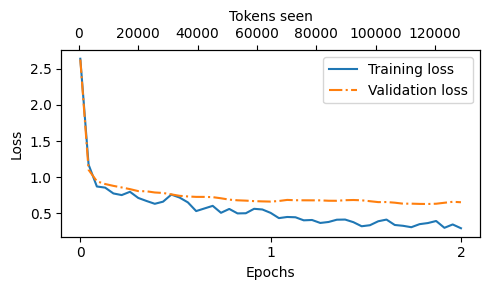

In [131]:
from previous_chapters import plot_losses

# 훈련 손실과 검증 손실 곡선 그리기
#   - linspace: 시작과 끝 사이를 균일하게 나눈 값들의 1차원 텐서를 생성
epochs_tensor = torch.linspace(0, num_epochs, len(train_loss))
plot_losses(
    epochs_tensor,
    tokens_seen,
    train_loss,
    val_loss
)

In [ ]:
# 연습문제 7.3: 원본 Alpaca 데이터셋에서 파인튜닝

url = "https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json"

In [ ]:
import time

start_time = time.time()
torch.manual_seed(123)

# weight_decay는 가중치 감쇠(Weight Decay)로, 과적합을 방지하기 위해 모델의 가중치 크기를 줄이는 정규화 기법입니다.
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 1

train_loss, val_loss , tokens_seen = train_model_simple(
    model,
    train_alpaca_dataloader,
    val_alpaca_dataloader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context=format_input(val_alpaca_data[0]),
    
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"총 훈련 시간: {execution_time_minutes:.2f} 분")

## Chapter 7 응답을 추출하여 저장하기 <a class="anchor" id="chapter6"></a>
1. 테스트 세트에 있는 입력데 대해 모델이 생성한 응답을 추출하여 수동으로 분석

2. LLM을 평가하여 응답의 품질을 정량화한다.

In [132]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    print(input_text)
    print(f"\n올바른 응답:\n>> {entry['output']}")
    print(f"\n모델 응답:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

올바른 응답:
>> The car is as fast as lightning.

모델 응답:
>> The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

올바른 응답:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

모델 응답:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

올바른 응답:
>> Jane Austen.

모델 응답:
>> The author of 'Pride and Prejudice' is Jane Austen.
---------------------------------

8. 자동화된 대화 벤치마크와 비슷한 방법을 구현한다.
   - 만은 인력을 동원하지 않고도 생성된 응답의 품질을 효율적으로 평가할 수 있다.

9. AlpacaEval의 방식에 따라서 다른 LLM을 사용해 미세 튜닝된 모델의 응답을 평가한다.
   - 공개 벤치마크 데이터셋에 의존하지 않고 예제에 있는 테스트 사례를 사용한다.
   - 이러한 커스터마이즈를 통해 지시 데이터셋에 표현된 사용 사례들을 고려하여 맞춤형으로 모델의 성능을 평가할 수 있다.

10. 평가 응답을 준비하기 위해 test_data 딕셔너리에 생성된 모델 응답을 추가하여 저장한다.

In [133]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    test_data[i]['model_response'] = response_text

# 결과를 파일에 저장
with open("instruction-data-with-response.json", "w", encoding="utf-8") as file:
    json.dump(test_data, file, indent=4)

100%|██████████| 110/110 [11:15<00:00,  6.14s/it]


In [134]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a cheetah.'}


In [135]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"모델이 {file_name}에 저장되었습니다.")

모델이 gpt2-medium355M-sft.pth에 저장되었습니다.


## Chapter 8 미세 튜닝된 LLM 평가하기 <a class="anchor" id="chapter8"></a>
1. 더 큰 다른 LLM으로 미세튜닝된 LLM의 응답을 자동으로 평가한다.
   - 메타 AI에서 개발한 80억 개의 파라미터 규모의 Llama3 모델의 지시 미세 튜닝된 버전을 사용한다.
   - Ollama는 랩톱에서 효율적으로 LLM을 실행할 수 있는 애플리케이션이다.
   - https://ollama.com/에서 다운로드할 수 있다.
      - 리눅스용 다운로드 : curl -fsSL https://ollama.com/install.sh | sh

2.Ollama 서버 실행
   - OLLAMA_HOST=127.0.0.1:11435 ollama serve

3. Ollama3 모델 시작 
   - ollama run llama3

In [1]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(['name']):
        if process_name in proc.info['name']:
            running = True
            break
    return running

ollama_running = check_if_running('ollama')

if not ollama_running:
    raise RecursionError("Ollama가 실행 중이지 않습니다. Ollama를 시작한 후 다시 시도하세요.")

print("Ollama 실행: ", check_if_running('ollama'))


Ollama 실행:  True


In [2]:
# 이 셀은 선택 사항입니다. 노트북을 다시 시작했을 때 이전 코드를 다시 실행하지 않고 섹션 7.7만 실행할 수 있습니다.
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [9]:
# 로컬 Ollama 모델에 쿼리하기
import urllib.request

def query_model(prompt, model='llama3', url='http://localhost:11434/api/chat'):
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options":{
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }
    
    payload = json.dumps(data).encode("utf-8")
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")
    
    response_data = ""
    with urllib.request.urlopen(request) as response:
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]
    return response_data

In [10]:
model = "llama3"
result = query_model("What do Llamas eat?", model=model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy munching on hay cubes or loose hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their diet. However, it's essential to provide these in moderation, as they can be high in calories and sugar.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas need access to mineral supplements, which provide essential nutrients like calcium, phosphorus, and salt.

In the wild, llamas might also eat:

1. Leaves: They'll munch on leaves from trees and shrubs, like willow or cedar.
2. Bark: In some cases, llamas may eat the bark of ce

3. 미세 튜닝된 모델의 응답을 0에서 100 사이의 척도로 평가한다. 
   - 처음 3개의 샘플 적용

In [12]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\n데이터셋 응답:")  # Dataset response
    print(">>", entry['output'])
    print("\n모델 응답:")  # Model response
    print(">>", entry["model_response"])
    print("\n점수:")  # Score
    print(">>", query_model(prompt))
    print("\n-------------------------")
    


데이터셋 응답:
>> The car is as fast as lightning.

모델 응답:
>> The car is as fast as a cheetah.

점수:
>> I'd rate the model response "The car is as fast as a cheetah." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to that of a cheetah.
* Cheetahs are known for their incredible speed, making them a relevant and effective comparison for describing a fast car.
* The phrase "as fast as" is used correctly to introduce the simile.

The only reason I wouldn't give it a perfect score is that lightning is often used as an example of extremely rapid movement in English language, so using a cheetah instead might not be as universally recognized or evocative. However, a cheetah is still a very fast animal, and the comparison is clear and effective.

Overall, I think the model response is well-written and effectively conveys the idea that the car is very fast!

-------------------------

데이터셋 응답:
>> The type of cloud typically associated with thunde

4. 0~100 사이의 정수 점수만 생성하도록 프롬프트 수정

In [13]:
def generate_model_scores(json_data, json_key, model='llama3'):
    scores = []
    for entry in tqdm(json_data, desc="평가항목"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Response with the integer score only."
        )
        score = query_model(prompt, model=model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"점수로 반환할 수 없습니다 : '{score}'")
            continue
        
    return scores

5. 평가 결과를 보면 미세튜닝된 모델이 평균적으로 48점을 달성한다.
   - 다른 모델과 비교하거나 성능 향상을 위해 다른 훈련 설정할 때 유용한 기준이 된다.

In [14]:
scores = generate_model_scores(test_data, "model_response", model="llama3")
print(f"평가 횟수: {len(test_data)}개 중 {len(scores)}개 성공")
print(f"평가 점수: {sum(scores)/len(scores):.2f}\n")

평가항목: 100%|██████████| 110/110 [00:17<00:00,  6.40it/s]

평가 횟수: 110개 중 110개 성공
평가 점수: 48.92

